# Prac 02
For this homework you will have to complete and implement the colour balancing for:
* Gray world algorithm
* Scale-by-max algorithm

You are free to use your own images. Experiment with more images and think about the effect each of the algorithms has on the resulting (balanced) image.

### Colour Balancing
In this notebook we will show different type of colour balancing making use of von Kries' hypothesis.

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 5]

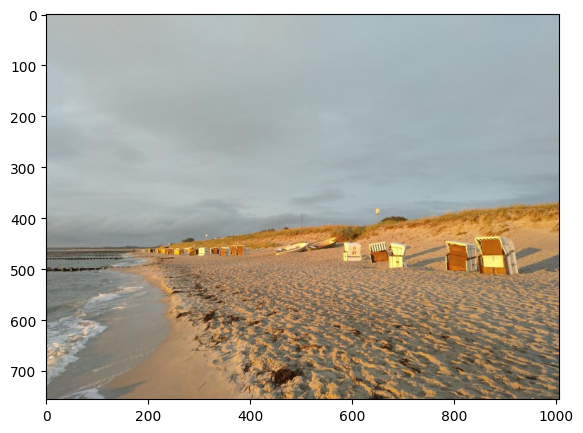

In [2]:
img = cv2.imread('./data/sea.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

In [3]:
img.shape

(756, 1008, 3)

### White patch
In white patch algorithm we choose a group of pixels we know they should be white. We then scale the resulting image colour channels by this white patch.

(<Axes: >, <matplotlib.image.AxesImage at 0x2767e266e40>)

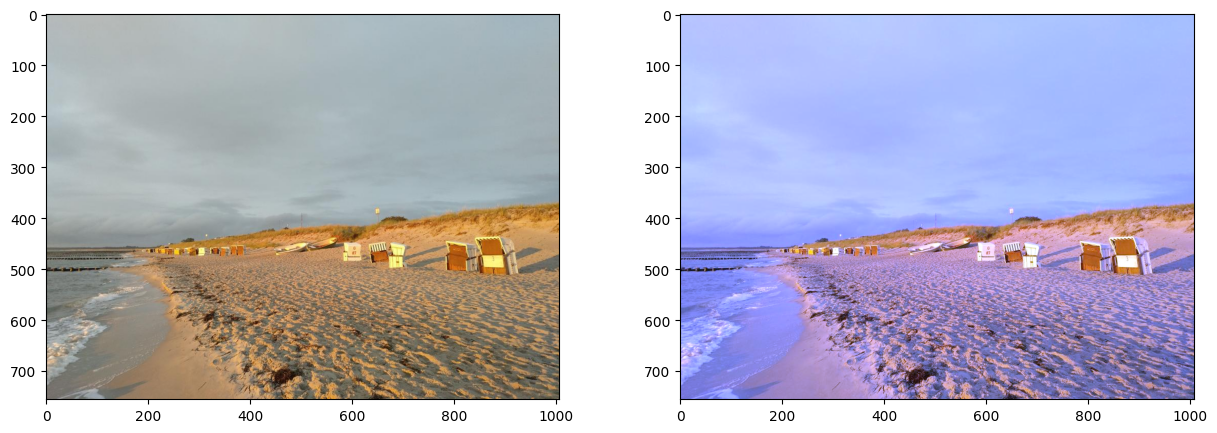

In [6]:
# Define white patch and the coefficients
row, col = 485, 864
white = img[row, col, :]
coeffs = 255.0/white

# Apply white balancing and generate balanced image
balanced = np.zeros_like(img, dtype=np.float32)
for channel in range(3):
    balanced[..., channel] = img[..., channel] * coeffs[channel]

# White patching does not guarantee that the dynamic range is preserved, images must be clipped.
balanced = balanced/255
balanced[balanced > 1] = 1

plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(balanced)

### Gray world
This algorithm assumes that a scene, on average, is gray.

(<Axes: >, <matplotlib.image.AxesImage at 0x23b82533ec0>)

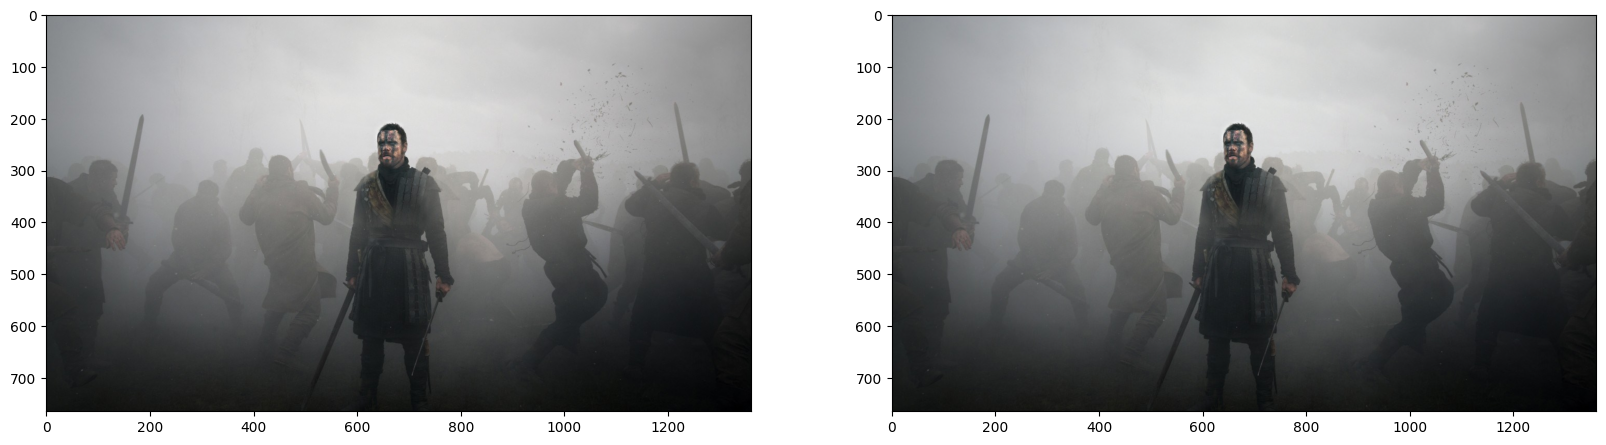

In [18]:
# Load your image
img = cv2.imread('./data/Macbeth.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Compute the mean values for all three colour channels (red, green, blue)
mean_r = img[..., 0].mean()
mean_g = img[..., 1].mean()
mean_b = img[..., 2].mean()

# Compute the coefficients kr, kg, kb
# Note: there are 3 coefficients to compute but we only have 2 equations.
# Therefore, you have to make an assumption, fix the value of one of the
# coefficients and compute the remining two
# Hint: You can fix the coefficient of the brightest colour channel to 1.
kr = 255/mean_r
kg = 255/mean_g
kb = 255/mean_b
coeffs = np.array([kr, kg, kb])
coeffs = coeffs.max() / coeffs

# Apply color balancing and generate the balanced image
balanced = img * coeffs
balanced = balanced/255
balanced[balanced > 1] = 1

# Show the original and the balanced image side by side
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(balanced)

In [4]:
def white_patch(img):
    mean_r = img[..., 0].mean()
    mean_g = img[..., 1].mean()
    mean_b = img[..., 2].mean()
    
    # Compute the coefficients kr, kg, kb
    # Note: there are 3 coefficients to compute but we only have 2 equations.
    # Therefore, you have to make an assumption, fix the value of one of the
    # coefficients and compute the remining two
    # Hint: You can fix the coefficient of the brightest colour channel to 1.
    kr = 255/mean_r
    kg = 255/mean_g
    kb = 255/mean_b
    coeffs = np.array([kr, kg, kb])
    coeffs = coeffs.max() / coeffs
    
    # Apply color balancing and generate the balanced image
    balanced = img * coeffs
    balanced = balanced/255
    balanced[balanced > 1] = 1
    
    return balanced

(<Axes: >,
 (np.float64(-0.5), np.float64(1199.5), np.float64(749.5), np.float64(-0.5)))

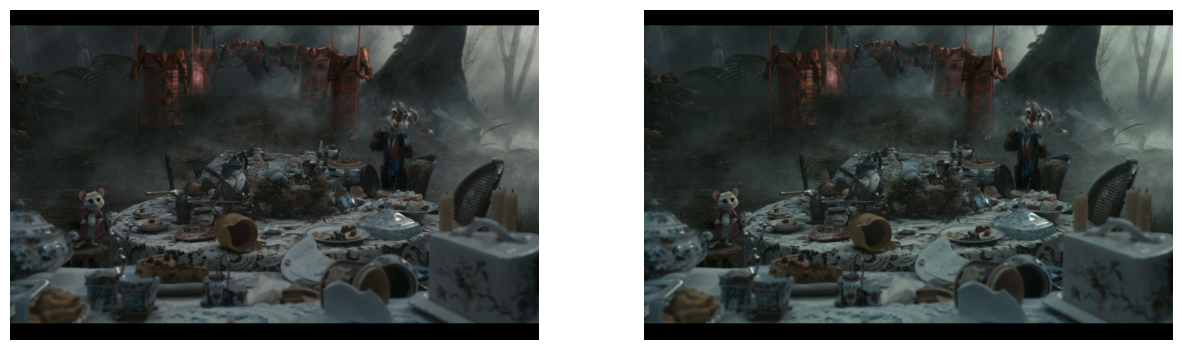

In [14]:
# Load your image
img1 = cv2.imread('./data/tea_party_at_mad_hatter.jpg')
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
balanced_img1 = white_patch(img1)

img2 = cv2.imread("./data/banshees_of_Inisherin.jpg")
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
balanced_img2 = white_patch(img2)


plt.subplot(121), plt.imshow(img1), plt.axis("off")
plt.subplot(122), plt.imshow(balanced_img1), plt.axis("off")



(<Axes: >,
 (np.float64(-0.5), np.float64(1079.5), np.float64(611.5), np.float64(-0.5)))

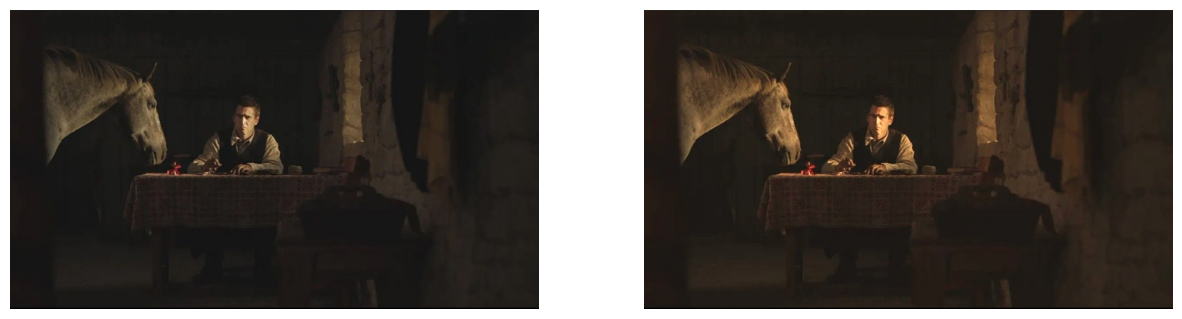

In [16]:
plt.subplot(121), plt.imshow(img2), plt.axis("off")
plt.subplot(122), plt.imshow(balanced_img2), plt.axis("off")

### Scale-by-max
This is a straightforward algorithm that scales each colour channel by its maximum value. Note that it is sensitive to noise and saturations.

(<Axes: >, <matplotlib.image.AxesImage at 0x23b8160fc50>)

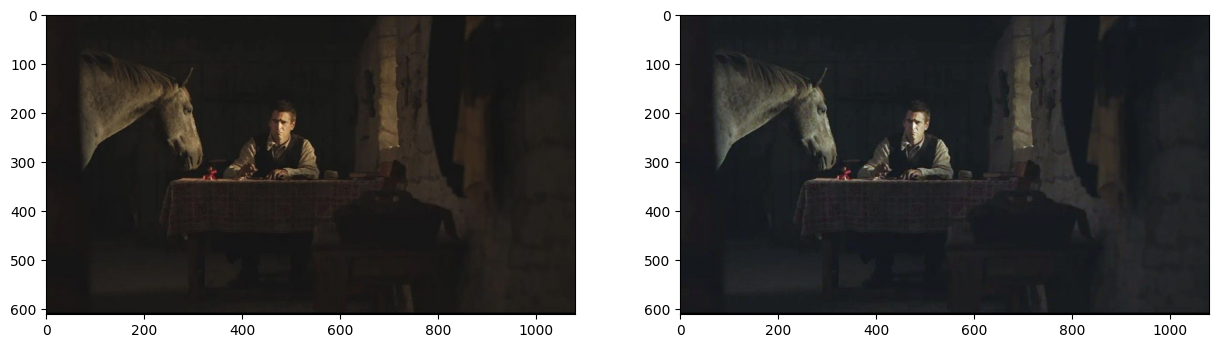

In [15]:
# Load your image
img = cv2.imread("./data/banshees_of_Inisherin.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Compute the maximum values for all three colour channels (red, green, blue)
max_r = img[..., 0].max()
max_g = img[..., 1].max()
max_b = img[..., 2].max()

coeffs = np.array([255/max_r, 255/max_g, 255/max_b])
# Apply scale-by-max balancing and generate the balanced image
balanced = img * coeffs
balanced = np.clip(balanced/255, 0, 1)

plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(balanced)